# 2026 Spring DSAA 2011 Maching Learning
## Lab Note 06
*Shuyu Shen, Suizi Huang, Yang Luo, Zixin Zhong* \
*Hong Kong University of Science and Technology (Guangzhou)*

**Question 1: Analysis of SVM Classification Performance**  

When using Support Vector Machines (SVMs) for a **binary classification** task, the following two sets of experimental results were observed. Please **analyze the possible reasons based on the principles of SVM**:  

**Experimental Results:**  
1. **Case 1:**  
   - Training set accuracy: **90%**  
   - Validation set accuracy: **90%**  
   - Test set accuracy: **88%**  

2. **Case 2:**  
   - Training set accuracy: **98%**  
   - Validation set accuracy: **90%**  
   - Test set accuracy: **88%**  

**Tips:**  
Consider the principle of **SVM as a soft-margin classifier**, where the optimization problem is formulated as follows:  

\begin{aligned}  
 \min_{(\mathbf{\theta}, \theta_0) \in \mathbb{R}^d \times \mathbb{R}} \frac{1}{2} \| \mathbf{\theta} \|^2 & + C\sum_{t=1}^{n} \epsilon_t \\  
 \text{s.t.} \quad y_t ( x_t^T \mathbf{\theta} + \theta_0) & \geq 1 - \epsilon_t, \quad \forall t=1,2,\dots,n \\  
\epsilon_t & \geq 0, \quad \forall t=1,2,\dots,n  
\end{aligned}  

**Key Questions for Analysis:**  
- How does the choice of **regularization parameter** \( C \) influence the decision boundary and generalization ability?  
- What do these accuracy patterns suggest about **underfitting** vs. **overfitting**?  
- Why does the second case have higher training accuracy but the same validation and test accuracy as the first case?  
- What adjustments can be made to improve generalization performance?  

Provide a detailed explanation based on the principles of **SVM margin theory**, **soft-margin classification**, and **model generalization**.


1. When the accuracy of the training set, validation set, and test set are all around 90%, it suggests that the model has **NOT** yet overfitted, and the accuracy is not very high. This indicates that the model is too tolerant of errors, leading to a margin that is wider than necessary. To improve performance, we can **increase the value of C** and retrain the model. A larger C will enforce a stricter classification boundary.  

2. When the training set accuracy is 98%, but the validation and test set accuracy remain at 90%, it suggests **overfitting**. The model has learned the training data too well but fails to generalize to unseen data. This occurs because the margin is too small, making the model too complex and sensitive to noise. To address this, we can **reduce the value of C**, which allows for a larger margin and better generalization.  

**Question 2.** Compare different $\ell_p$-norm for regularization.

**Tasks**
- Train your polynomial regression model with different $\ell_p$-norm regularizations (Lasso and Ridge).
- Compare the performance of Lasso and Ridge regression.
- Discuss the impact of Lasso and Ridge regularization.


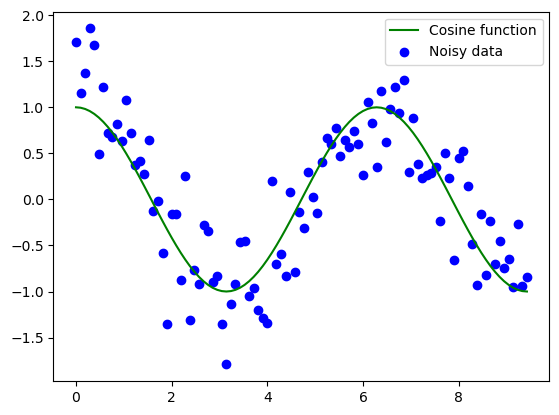

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)
X = np.linspace(0, 3 * np.pi, 100).reshape(-1, 1)
y = np.cos(X).ravel() + np.random.normal(0, 0.4, X.shape[0])

y_ = np.cos(X).ravel()
# plot the data
plt.plot(X, y_, color='g', label='Cosine function')
plt.scatter(X, y, color='blue', label='Noisy data')
plt.legend()
plt.show()

Lasso MSE: 0.3100055033896545


C:\Users\Suizi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:631: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.140e+01, tolerance: 6.442e-03
  model = cd_fast.enet_coordinate_descent(


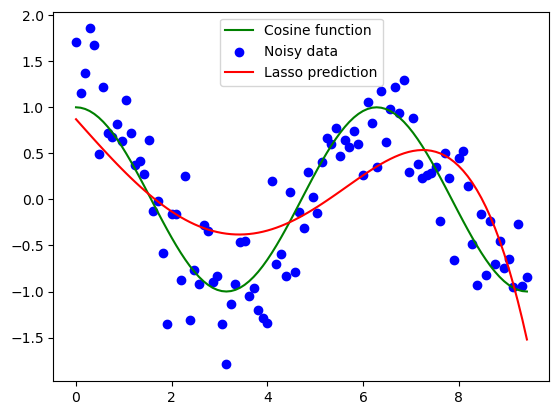

In [2]:
# ===================== Your Code Here =====================
# ==========================================================
from sklearn.linear_model import Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

poly = PolynomialFeatures(degree=6)
X_poly = poly.fit_transform(X)

# lasso regression
lasso = Lasso(alpha=0.1)
lasso.fit(X_poly, y)
y_pred_lasso = lasso.predict(X_poly)
lasso_mse = mean_squared_error(y, y_pred_lasso)
print(f"Lasso MSE: {lasso_mse}")

# plot the result
plt.plot(X, y_, color='g', label='Cosine function')
plt.scatter(X, y, color='blue', label='Noisy data')
plt.plot(X, y_pred_lasso, color='red', label='Lasso prediction')
plt.legend()
plt.show()

Ridge MSE: 0.13938658374587637


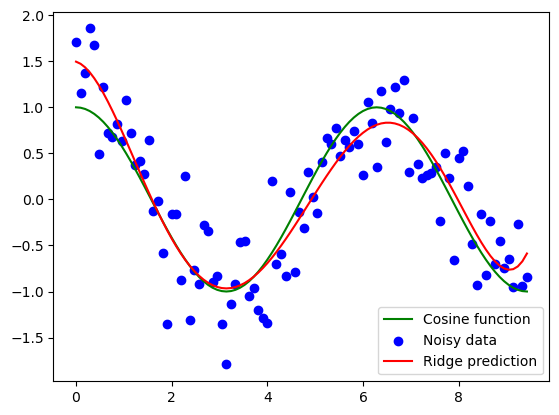

In [3]:
# ridge regression
ridge = Ridge(alpha=0.1)
ridge.fit(X_poly, y)
y_pred_ridge = ridge.predict(X_poly)
ridge_mse = mean_squared_error(y, y_pred_ridge)
print(f"Ridge MSE: {ridge_mse}")

# plot the result
plt.plot(X, y_, color='g', label='Cosine function')
plt.scatter(X, y, color='blue', label='Noisy data')
plt.plot(X, y_pred_ridge, color='red', label='Ridge prediction')
plt.legend()
plt.show()

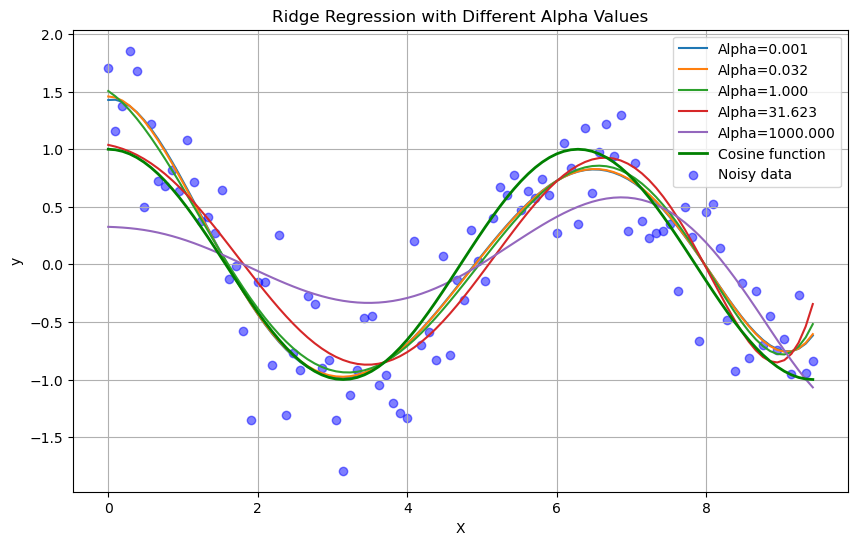

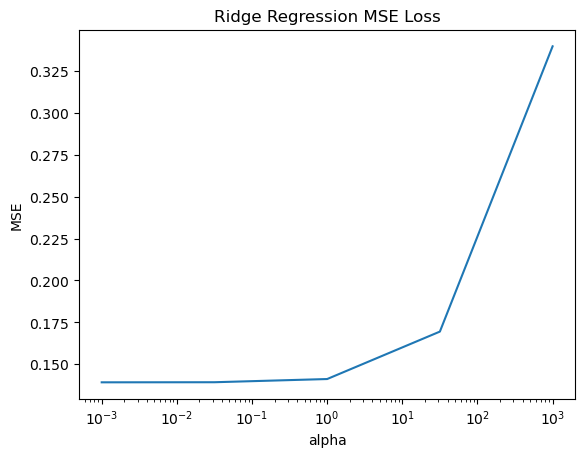

In [4]:
# ridge regression with different alpha values
alphas = np.logspace(-3, 3, 5)
ridge_mses = []
fig = plt.figure(figsize=(10, 6))
for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_poly, y)
    y_pred_ridge = ridge.predict(X_poly)
    ridge_mse = mean_squared_error(y, y_pred_ridge)
    ridge_mses.append(ridge_mse)
    plt.plot(X, y_pred_ridge, label=f'Alpha={alpha:.3f}')

plt.plot(X, y_, color='g', label='Cosine function', linewidth=2)
plt.scatter(X, y, color='blue', label='Noisy data', alpha=0.5)
plt.legend()
plt.xlabel("X")
plt.ylabel("y")
plt.title("Ridge Regression with Different Alpha Values")
plt.grid(True)
plt.show()

# plot the mse loss

fig = plt.figure()
plt.plot(alphas, ridge_mses)
plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.title('Ridge Regression MSE Loss')
plt.show()

# plot the result


### discuss the impact of different p-norm in regularization

In machine learning, regularization is used to prevent overfitting by penalizing large coefficients in a model. The idea behind regularization is to add a penalty term to the loss function that discourages large values for the model parameters. The most commonly used regularizations are based on different ℓ_p-norms (p-norms), specifically Lasso and Ridge regression.

 **1. $\ell_p$ Norms:**
The $\ell_p$-norm is a measure of the magnitude of a vector, and it is defined as:

$$ \|w\|_p = \left(\sum_{i=1}^{n} |w_i|^p \right)^{1/p} $$

where:
- $( w_i )$ are the components of the weight vector $( w )$,
- $( p \geq 1 )$.

For different values of $( p )$, we get different types of norms:

- $\ell_1$-norm (Manhattan norm): $ ( p = 1 ) $
- $\ell_2$-norm (Euclidean norm): $ ( p = 2 ) $
- $\ell_\infty$-norm (Max norm): $( p = \infty )$

In the context of regularization in regression problems, the most important cases are Lasso and Ridge regression, which correspond to the $\ell_1$-norm and $\ell_2$-norm, respectively.

**2. Lasso (L1 Regularization):**
Lasso (Least Absolute Shrinkage and Selection Operator) regression uses the $\ell_1$-norm for regularization. The loss function for Lasso is:

$$ \text{Loss}_{\text{Lasso}} = \text{RSS} + \lambda \|w\|_1 = \text{RSS} + \lambda \sum_{i=1}^{n} |w_i| $$

Where:
- RSS: Residual Sum of Squares (the usual least squares error),
- $( \|w\|_1 )$: The $\ell_1$ regularization term, which is the sum of the absolute values of the weights,
- $( \lambda )$: The regularization parameter, controlling the strength of regularization.

**3. Ridge Regression (L2 Regularization):**
Ridge regression uses the ℓ₂-norm for regularization. The loss function for Ridge is:

$$ \text{Loss}_{\text{Ridge}} = \text{RSS} + \lambda \|w\|_2^2 = \text{RSS} + \lambda \sum_{i=1}^{n} w_i^2 $$

Where:
- RSS: Residual Sum of Squares,
- $( \|w\|_2^2 )$: The squared ℓ₂-norm of the weight vector,
- $( \lambda )$: The regularization parameter.

**4. Comparison of Lasso and Ridge Regression:**

| Aspect                     | Lasso Regression (L1)                                                    | Ridge Regression (L2)                                                        |
|----------------------------|--------------------------------------------------------------------------|------------------------------------------------------------------------------|
| **Penalty Term**            | $\|w\|_1$                                                            | $\|w\|_2^2$                                                            |
| **Sparsity**                | Produces sparse models (some coefficients become exactly zero)           | Does not produce sparse models, coefficients are shrunk but not zeroed out   |
| **Feature Selection**       | Yes, it can select important features by setting some coefficients to zero | No, keeps all features in the model                                          |
| **Interpretability**        | More interpretable (fewer features selected)                             | Less interpretable (all features remain)                                     |
| **Handling Correlated Features** | Struggles with highly correlated features                                | Handles highly correlated features better                                    |
| **Computation**             | Can be more computationally expensive due to non-differentiability at zero | Computationally easier and faster (differentiable)                           |
| **Use Case**                | When you need a sparse model or feature selection                        | When you want to shrink coefficients without completely eliminating features |


 **Question 3.** Use the grid search method to select the model for the breast cancer dataset.
Breast cancer diagnosis is a critical medical application where accurate classification can significantly impact patient outcomes and treatment planning. The ability to reliably distinguish between malignant and benign tumors helps healthcare professionals with early detection and diagnosis.

Tasks:
1. For SVM model, find optimal hyperparameters using manual grid search.

2. Evaluate and compare the best models.


In [5]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y)}")




Dataset shape: (569, 30)
Number of classes: 2
Class distribution: [212 357]


Performing manual grid search...

Top 10 best performing models:
        C  kernel  gamma  val_accuracy
0     0.1  linear  scale      0.988235
13    1.0  linear   auto      0.988235
42  100.0     rbf  0.001      0.988235
30   10.0     rbf  0.001      0.988235
29   10.0     rbf   auto      0.988235
28   10.0     rbf  scale      0.988235
27   10.0  linear   0.01      0.988235
26   10.0  linear  0.001      0.988235
25   10.0  linear   auto      0.988235
1     0.1  linear   auto      0.988235

Best parameters: {'C': 0.1, 'kernel': 'linear', 'gamma': 'scale'}
Best validation accuracy: 0.9882
Test accuracy with best model: 0.9535


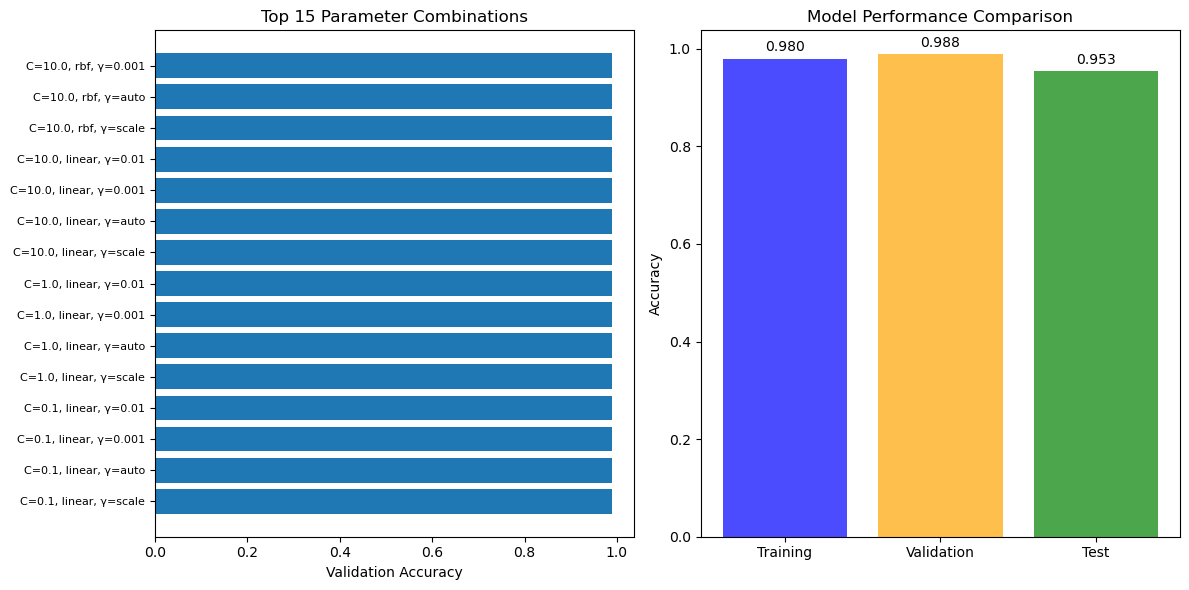

In [6]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42, stratify=y_val)

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.001, 0.01]
}

# Manual grid search
print("Performing manual grid search...")
best_score = 0
best_params = {}
best_model = None
results = []

for C in param_grid['C']:
    for kernel in param_grid['kernel']:
        for gamma in param_grid['gamma']:
            # Create and train SVM model
            model = SVC(C=C, kernel=kernel, gamma=gamma, random_state=42)
            model.fit(X_train_scaled, y_train)
            
            # Evaluate on validation set
            y_val_pred = model.predict(X_val_scaled)
            val_accuracy = accuracy_score(y_val, y_val_pred)
            
            # Store results
            results.append({
                'C': C,
                'kernel': kernel,
                'gamma': gamma,
                'val_accuracy': val_accuracy
            })
            
            # Update best model
            if val_accuracy > best_score:
                best_score = val_accuracy
                best_params = {'C': C, 'kernel': kernel, 'gamma': gamma}
                best_model = model

# Display results
results_df = pd.DataFrame(results)
print("\nTop 10 best performing models:")
print(results_df.sort_values('val_accuracy', ascending=False).head(10))

print(f"\nBest parameters: {best_params}")
print(f"Best validation accuracy: {best_score:.4f}")

# Evaluate best model on test set
y_test_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test accuracy with best model: {test_accuracy:.4f}")

# Visualization of results
plt.figure(figsize=(12, 6))

# Plot accuracy by parameter combinations
plt.subplot(1, 2, 1)
top_models = results_df.nlargest(15, 'val_accuracy')
plt.barh(range(len(top_models)), top_models['val_accuracy'])
plt.yticks(range(len(top_models)), [f"C={row['C']}, {row['kernel']}, γ={row['gamma']}" 
                                   for _, row in top_models.iterrows()], fontsize=8)
plt.xlabel('Validation Accuracy')
plt.title('Top 15 Parameter Combinations')
plt.tight_layout()

plt.subplot(1, 2, 2)
# Compare training, validation and test performance
train_accuracy = accuracy_score(y_train, best_model.predict(X_train_scaled))
accuracies = [train_accuracy, best_score, test_accuracy]
labels = ['Training', 'Validation', 'Test']
plt.bar(labels, accuracies, color=['blue', 'orange', 'green'], alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

**Question 4.** Multiclass classification with SVM using the Wine dataset.

In the wine industry, accurate classification of wines based on their chemical properties can help with Quality control and assurance, Authentication of wine origins ,Production process optimization.

- **Dataset**: Wine Recognition Dataset from scikit-learn.
- **Task**: Multiclass classification to identify wine types based on chemical analysis.

a) Find the optimal hyperparameters for Support Vector Machine classifier.

- Split data into training and test sets with stratification.
- Standardize features for SVM performance.
- Define comprehensive parameter grid (C, kernel, gamma, degree).
- Test all parameter combinations and identify best performing model.

b) Conduct thorough evaluation of the optimized SVM model using multiple metrics and visualizations for multiclass classification.

- Calculate comprehensive performance metrics (accuracy, precision, recall, F1-score).
- Generate confusion matrix and classification report.
- Visualize feature importance and model performance.

In [7]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_wine


# Set random seed for reproducibility
np.random.seed(42)

# Load dataset
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset Shape: {X.shape}")
print(f"Number of Features: {len(feature_names)}")
print(f"Target Classes: {target_names}")
print(f"Class Distribution: {np.bincount(y)}")



Dataset Shape: (178, 13)
Number of Features: 13
Target Classes: ['class_0' 'class_1' 'class_2']
Class Distribution: [59 71 48]


In [8]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, 
                           classification_report)

# Split data into training, validation and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

# Data standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Define SVM parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.1, 1],
    'degree': [2, 3]  # Only for poly kernel
}

print("Starting manual parameter search...")
best_score = 0
best_params = {}
best_model = None
results = []

# Manual parameter search
for C in param_grid['C']:
    for kernel in param_grid['kernel']:
        for gamma in param_grid['gamma']:
            for degree in param_grid['degree']:
                # Skip degree parameter if kernel is not poly
                if kernel != 'poly' and degree != param_grid['degree'][0]:
                    continue
                    
                # Create and train SVM model
                model = SVC(C=C, kernel=kernel, gamma=gamma, degree=degree, random_state=42, probability=True)
                model.fit(X_train_scaled, y_train)
                
                # Evaluate on validation set
                y_val_pred = model.predict(X_val_scaled)
                val_accuracy = accuracy_score(y_val, y_val_pred)
                
                # Store results
                results.append({
                    'C': C,
                    'kernel': kernel,
                    'gamma': gamma,
                    'degree': degree,
                    'val_accuracy': val_accuracy
                })
                
                # Update best model
                if val_accuracy > best_score:
                    best_score = val_accuracy
                    best_params = {'C': C, 'kernel': kernel, 'gamma': gamma, 'degree': degree}
                    best_model = model

# Display results
results_df = pd.DataFrame(results)
print("\nTop 10 best performing models:")
print(results_df.sort_values('val_accuracy', ascending=False).head(10))

print(f"\nBest parameters: {best_params}")


Starting manual parameter search...

Top 10 best performing models:
        C  kernel  gamma  degree  val_accuracy
32   10.0  linear  scale       2           1.0
16    1.0  linear  scale       2           1.0
33   10.0  linear   auto       2           1.0
34   10.0  linear    0.1       2           1.0
35   10.0  linear      1       2           1.0
51  100.0  linear      1       2           1.0
50  100.0  linear    0.1       2           1.0
49  100.0  linear   auto       2           1.0
48  100.0  linear  scale       2           1.0
19    1.0  linear      1       2           1.0

Best parameters: {'C': 1, 'kernel': 'linear', 'gamma': 'scale', 'degree': 2}


In multiclass classification problems, we use **macro averaging** to compute performance metrics. The **macro** method calculates metrics for each class independently and then takes the unweighted mean across all classes.

Test Set Accuracy: 0.9722

Training Accuracy: 1.0000
Test Accuracy: 0.9722
Macro Precision: 0.9778
Macro Recall: 0.9667
Macro F1-Score: 0.9710

Detailed Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       0.93      1.00      0.97        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.97        36
   macro avg       0.98      0.97      0.97        36
weighted avg       0.97      0.97      0.97        36



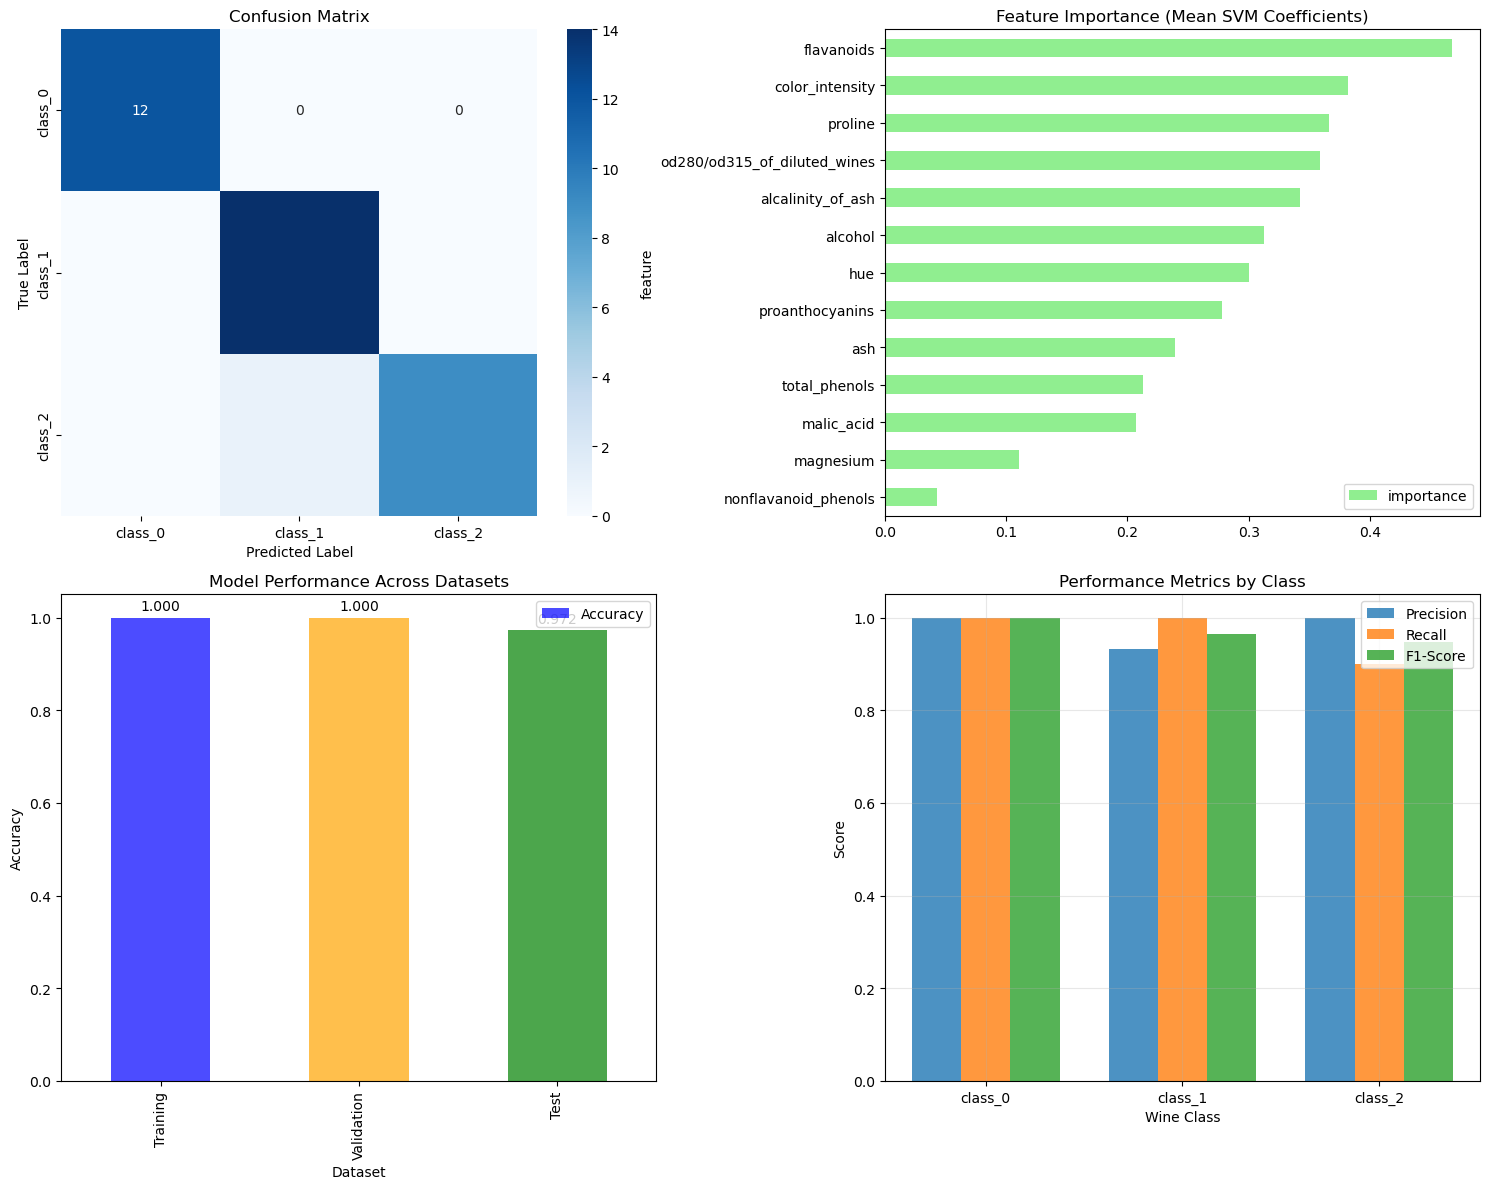


MODEL PERFORMANCE SUMMARY
Best Parameters: {'C': 1, 'kernel': 'linear', 'gamma': 'scale', 'degree': 2}
Final Test Accuracy: 0.9722


In [9]:
y_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# Predictions for evaluation
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Multiclass precision, recall, F1 (macro average)
precision = precision_score(y_test, y_test_pred, average='macro')
recall = recall_score(y_test, y_test_pred, average='macro')
f1 = f1_score(y_test, y_test_pred, average='macro')

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")
print(f"Macro F1-Score: {f1:.4f}")

# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=target_names))

# Visualization of results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names, ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted Label')
axes[0,0].set_ylabel('True Label')

# 2. Feature Importance (based on linear SVM coefficients)
if hasattr(best_model, 'coef_'):
    # For multiclass, take mean absolute coefficients across all classes
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': np.mean(np.abs(best_model.coef_), axis=0)
    }).sort_values('importance', ascending=True)
    
    feature_importance.plot(kind='barh', x='feature', y='importance', 
                           ax=axes[0,1], color='lightgreen')
    axes[0,1].set_title('Feature Importance (Mean SVM Coefficients)')
else:
    # For non-linear kernels, use feature std as proxy importance
    feature_std = pd.DataFrame({
        'feature': feature_names,
        'importance': np.std(X_train, axis=0)
    }).sort_values('importance', ascending=True)
    
    feature_std.plot(kind='barh', x='feature', y='importance', 
                    ax=axes[0,1], color='lightblue')
    axes[0,1].set_title('Feature Variability (Standard Deviation)')

# 3. Performance comparison (Training vs Validation vs Test)
accuracy_comparison = pd.DataFrame({
    'Dataset': ['Training', 'Validation', 'Test'],
    'Accuracy': [train_accuracy, best_score, test_accuracy]
})
accuracy_comparison.plot(kind='bar', x='Dataset', y='Accuracy', 
                        ax=axes[1,0], color=['blue', 'orange', 'green'], alpha=0.7)
axes[1,0].set_title('Model Performance Across Datasets')
axes[1,0].set_ylabel('Accuracy')
for i, v in enumerate([train_accuracy, best_score, test_accuracy]):
    axes[1,0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 4. Performance comparison across classes
class_metrics = []
for i, class_name in enumerate(target_names):
    class_precision = precision_score(y_test, y_test_pred, average=None)[i]
    class_recall = recall_score(y_test, y_test_pred, average=None)[i]
    class_f1 = f1_score(y_test, y_test_pred, average=None)[i]
    class_metrics.append({
        'Class': class_name,
        'Precision': class_precision,
        'Recall': class_recall,
        'F1-Score': class_f1
    })

metrics_df = pd.DataFrame(class_metrics)
x = np.arange(len(target_names))
width = 0.25

axes[1,1].bar(x - width, metrics_df['Precision'], width, label='Precision', alpha=0.8)
axes[1,1].bar(x, metrics_df['Recall'], width, label='Recall', alpha=0.8)
axes[1,1].bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', alpha=0.8)

axes[1,1].set_xlabel('Wine Class')
axes[1,1].set_ylabel('Score')
axes[1,1].set_title('Performance Metrics by Class')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(target_names)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model summary
print("\n" + "=" * 50)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 50)
print(f"Best Parameters: {best_params}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")